In [185]:
import sys, os

sys.path.insert(0, "../")

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
import time
from modules.Classes_v2 import Precessing as P2, LensingGeo
from modules.Classes_v3 import Precessing as P3, SOLMASS2SEC
from modules.default_params_v2 import *
from modules.functions_v2 import (
    set_to_location,
    calculate_cosJN,
    get_gw,
    get_lens_limits_for_RP_L,
    number_of_prec_cycles,
    number_of_lens_cycles,
    optimize_mismatch_gammaP as optimize_mismatch_gammaP_v2,
)
from modules.functions_v3 import optimize_mismatch_gammaP as optimize_mismatch_gammaP_v3
from modules.plot_utils_v3 import plot_standalone_waveform_comparison

plt.rcParams["figure.dpi"] = 200

In [63]:
params_Ben = RP_params_1.copy()

# Use Ben's angles
params_Ben.update(
    {
        "theta_S": np.pi / 3,
        "phi_S": np.pi / 4,
        "theta_J": np.pi / 6,
        "phi_J": np.pi / 3,
        "theta_tilde": 8,
        "omega_tilde": 3,
        "gamma_P": 0,
    }
)
cos_JN = calculate_cosJN(
    params_Ben["phi_S"],
    params_Ben["theta_S"],
    params_Ben["phi_J"],
    params_Ben["theta_J"],
)
print(cos_JN)

order of arguments: phi_S, theta_S, phi_J, theta_J
0.8512708537611233


In [64]:
p2_Ben = P2(params_Ben)
p3_Ben = P3(params_Ben)

# Frequency array
f_min = 20.0
f_cut = p2_Ben.f_cut()
f_arr = np.linspace(f_min, f_cut * 0.9, 2000)

# $\hat{L} \cdot \hat{N}$ as a function of $f$

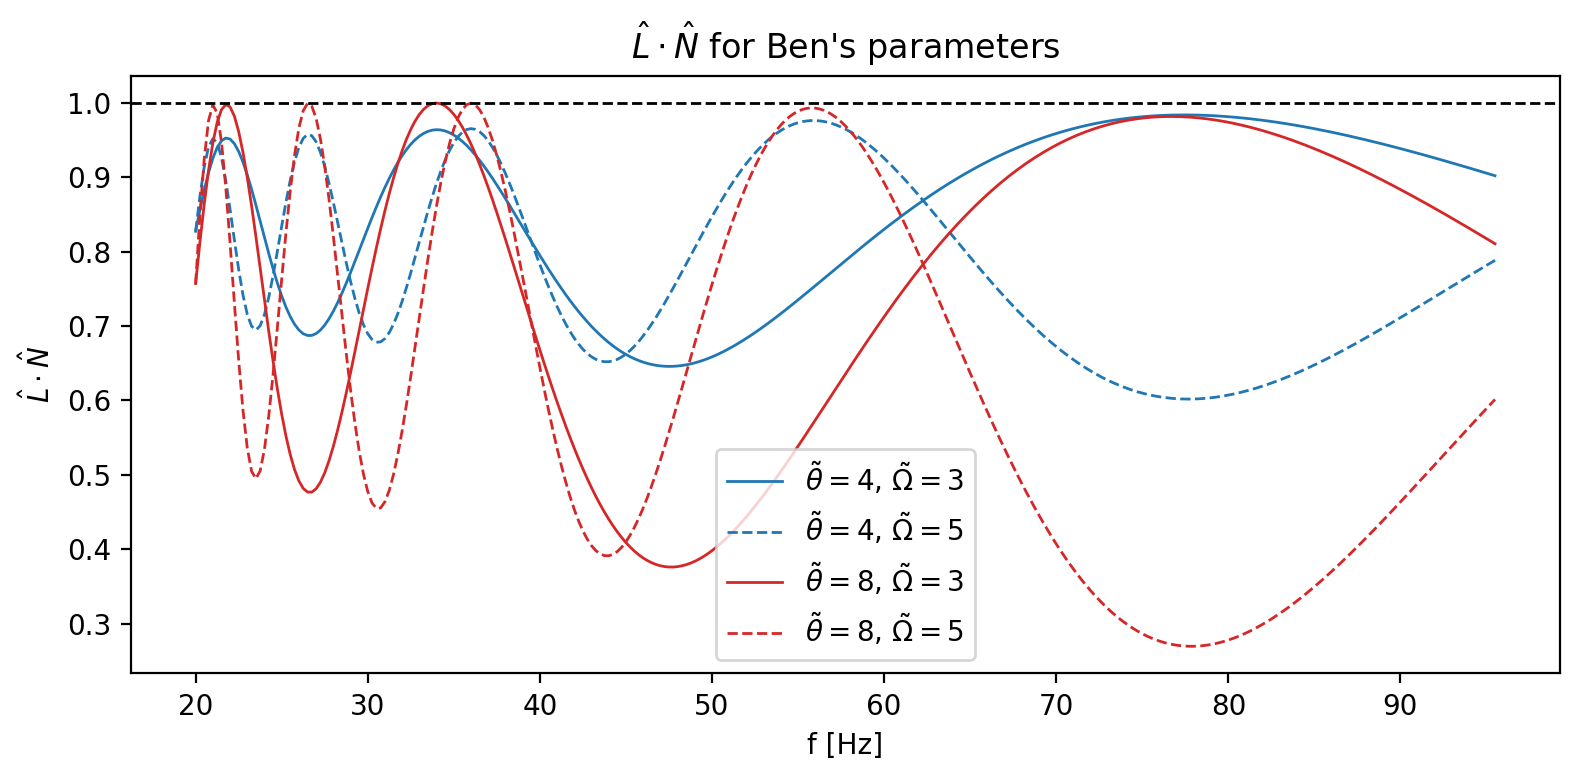

In [159]:
theta_vals = [4, 8]
omega_vals = [3, 5]
colors = ["tab:blue", "tab:red"]
linestyles = ["-", "--"]

plt.figure(figsize=(8, 4))
for i, theta in enumerate(theta_vals):
    for j, omega in enumerate(omega_vals):
        params_Ben_var = params_Ben.copy()
        params_Ben_var.update({"theta_tilde": theta, "omega_tilde": omega})
        p2_Ben_var = P2(params_Ben_var)
        LdotN_Ben_var = p2_Ben_var.LdotN(f_arr)
        label = rf"$\tilde{{\theta}}={theta}$, $\tilde{{\Omega}}={omega}$"
        plt.plot(
            f_arr,
            LdotN_Ben_var,
            label=label,
            lw=1,
            color=colors[i % len(colors)],
            ls=linestyles[j % len(linestyles)],
        )

plt.axhline(y=1, color="k", ls="--", lw=1)
plt.xlabel("f [Hz]")
plt.ylabel(r"$\hat{L} \cdot \hat{N}$")
plt.legend()
plt.title("$\hat{L} \cdot \hat{N}$ for Ben's parameters")
plt.tight_layout()
plt.show()

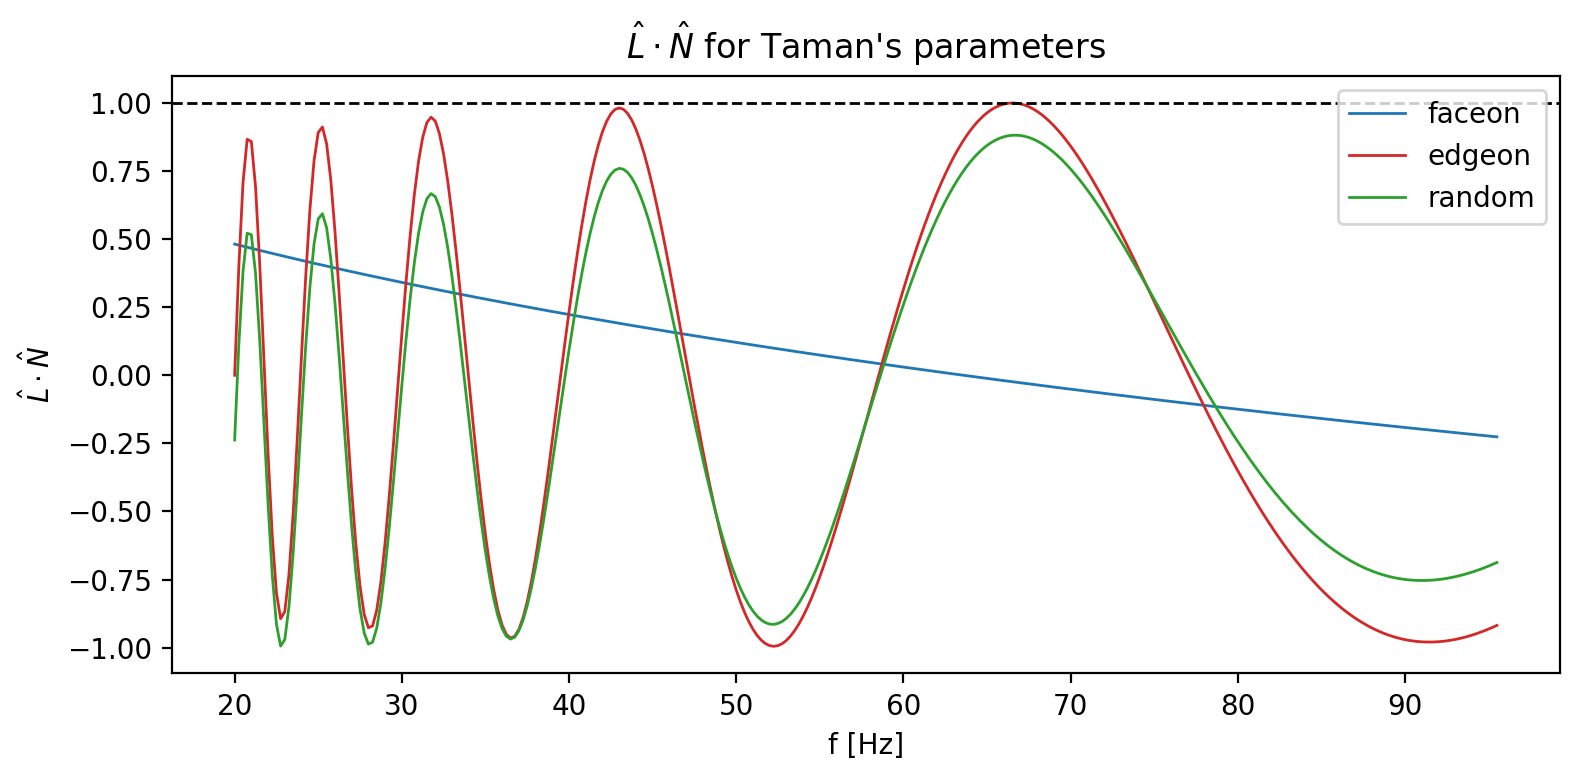

In [171]:
locations = ["faceon", "edgeon", "random"]
colors = ["tab:blue", "tab:red", "tab:green"]

plt.figure(figsize=(8, 4))
for loc, color in zip(locations, colors):
    params_Taman = RP_params_1.copy()
    params_Taman.update({"theta_tilde": 18, "omega_tilde": 6, "gamma_P": 0})
    (params_Taman,) = set_to_location(loc_params["Taman"][loc], params_Taman)
    p2_Taman = P2(params_Taman)
    LdotN2_Taman = p2_Taman.LdotN(f_arr)
    plt.plot(f_arr, LdotN2_Taman, label=f"{loc}", lw=1, color=color)

plt.axhline(y=1, color="k", ls="--", lw=1)
plt.xlabel("f [Hz]")
plt.ylabel(r"$\hat{L} \cdot \hat{N}$")
plt.legend()
plt.title("$\hat{L} \cdot \hat{N}$ for Taman's parameters")
plt.tight_layout()
plt.show()

# Compare $\delta \Phi$ integrand and integral from `Classes_v2.py` (ODE) vs `Classes_v3.py` (vectorized)
This section checks that the vectorized implementation in `modules/Classes_ver3.py` matches the original ODE-based implementation in `modules/Classes_ver2.py` for both the integrand and the integrated phase Δφ.

## Ben's parameters

In [194]:
# Compute integrands
%time integrand2_Ben = np.array([p2_Ben.integrand_delta_phi(0, fi) for fi in f_arr])
%time integrand3_Ben = p3_Ben._integrand_delta_phi_vec(f_arr)

# Integrate
%time phase2_Ben = np.atleast_1d(p2_Ben.phase_delta_phi(f_arr))
%time phase3_Ben = cumulative_trapezoid(integrand3_Ben, f_arr, initial=0.0)

print("Integrand L2 norm:", np.linalg.norm(integrand2_Ben - integrand3_Ben))
print("Phase L2 norm:", np.linalg.norm(phase2_Ben - phase3_Ben))

CPU times: user 20.3 ms, sys: 2.4 ms, total: 22.7 ms
Wall time: 23.3 ms
CPU times: user 302 µs, sys: 93 µs, total: 395 µs
Wall time: 399 µs
CPU times: user 42.8 ms, sys: 1.07 ms, total: 43.9 ms
Wall time: 45.1 ms
CPU times: user 88 µs, sys: 14 µs, total: 102 µs
Wall time: 105 µs
Integrand L2 norm: 0.0
Phase L2 norm: 11.079143054050002


cumtrapz in v3 is much faster than ODE integration in v2 by a factor of at least 100!!!

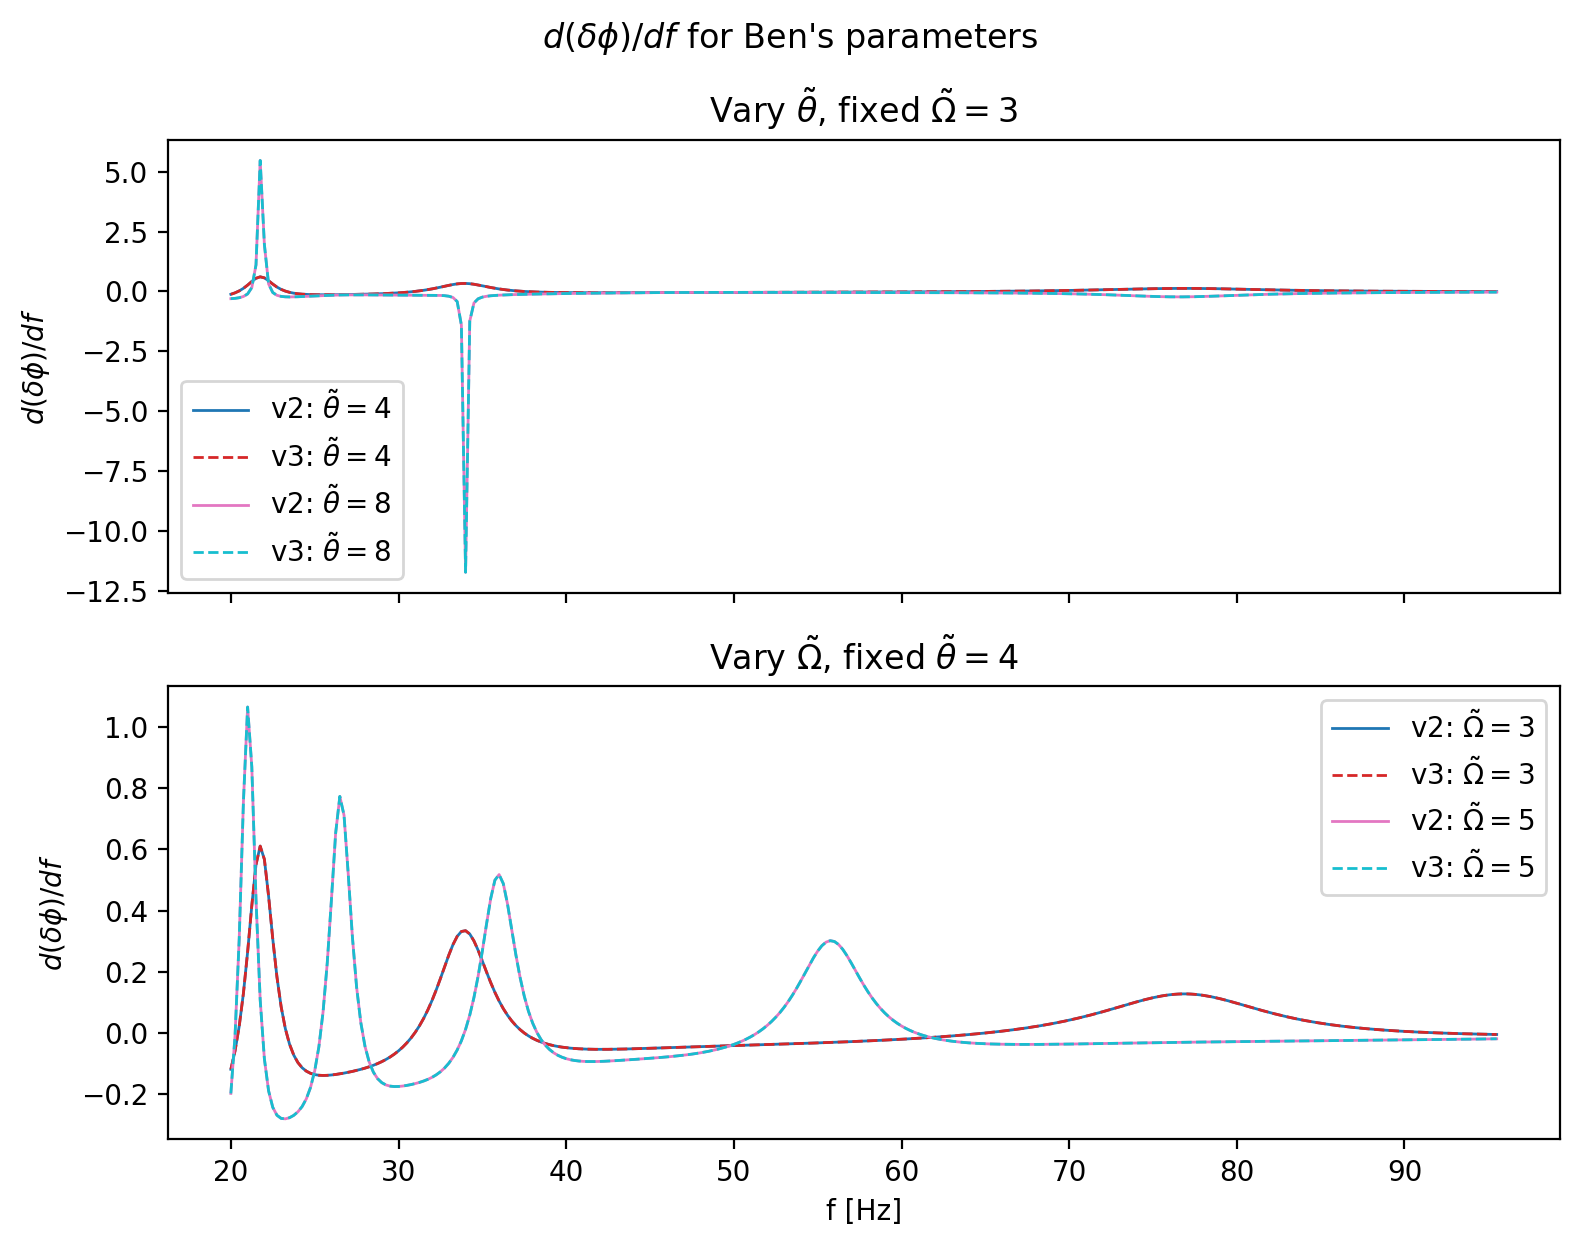

In [188]:
theta_vals = [4, 8]
omega_vals = [3, 5]

fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
colors_top = mpl.colormaps.get_cmap("tab10").resampled(2 * len(theta_vals))
colors_bot = mpl.colormaps.get_cmap("tab10").resampled(2 * len(omega_vals))


def plot_integrand_delta_phi(
    ax, which_params, var_vals, fixed, var_name, fixed_name, colors, idx=0
):
    # Map variable names to LaTeX symbols
    var_latex = {"theta_tilde": r"\tilde{\theta}", "omega_tilde": r"\tilde{\Omega}"}
    for i, var in enumerate(var_vals):
        params = which_params.copy()
        params.update({var_name: var, fixed_name: fixed})
        p2, p3 = P2(params), P3(params)
        int2 = np.array([p2.integrand_delta_phi(0, fi) for fi in f_arr])
        int3 = p3._integrand_delta_phi_vec(f_arr)
        label2 = rf"v2: ${var_latex.get(var_name, var_name)}={var}$"
        label3 = rf"v3: ${var_latex.get(var_name, var_name)}={var}$"
        ax.plot(f_arr, int2, label=label2, lw=1, color=colors(2 * i), ls="-")
        ax.plot(f_arr, int3, label=label3, lw=1, color=colors(2 * i + 1), ls="--")


# Top: vary theta_tilde, fix omega_tilde
plot_integrand_delta_phi(
    axs[0],
    params_Ben,
    theta_vals,
    omega_vals[0],
    "theta_tilde",
    "omega_tilde",
    colors_top,
)
axs[0].set_ylabel(r"$d(\delta\phi)/df$")
axs[0].set_title(rf"Vary $\tilde{{\theta}}$, fixed $\tilde{{\Omega}}={omega_vals[0]}$")
axs[0].legend(fontsize=10)

# Bottom: vary omega_tilde, fix theta_tilde
plot_integrand_delta_phi(
    axs[1],
    params_Ben,
    omega_vals,
    theta_vals[0],
    "omega_tilde",
    "theta_tilde",
    colors_bot,
)
axs[1].set_xlabel("f [Hz]")
axs[1].set_ylabel(r"$d(\delta\phi)/df$")
axs[1].set_title(rf"Vary $\tilde{{\Omega}}$, fixed $\tilde{{\theta}}={theta_vals[0]}$")
axs[1].legend(fontsize=10)

plt.tight_layout()
plt.suptitle(r"$d(\delta\phi)/df$ for Ben's parameters", y=1.03)
plt.show()

At $\tilde{\theta} = 8$ and $\tilde{\Omega} = 3$, $d(\delta\phi)/df$ jumps at about the same frequencies where $\hat{L} \cdot \hat{N}$ crosses 1.

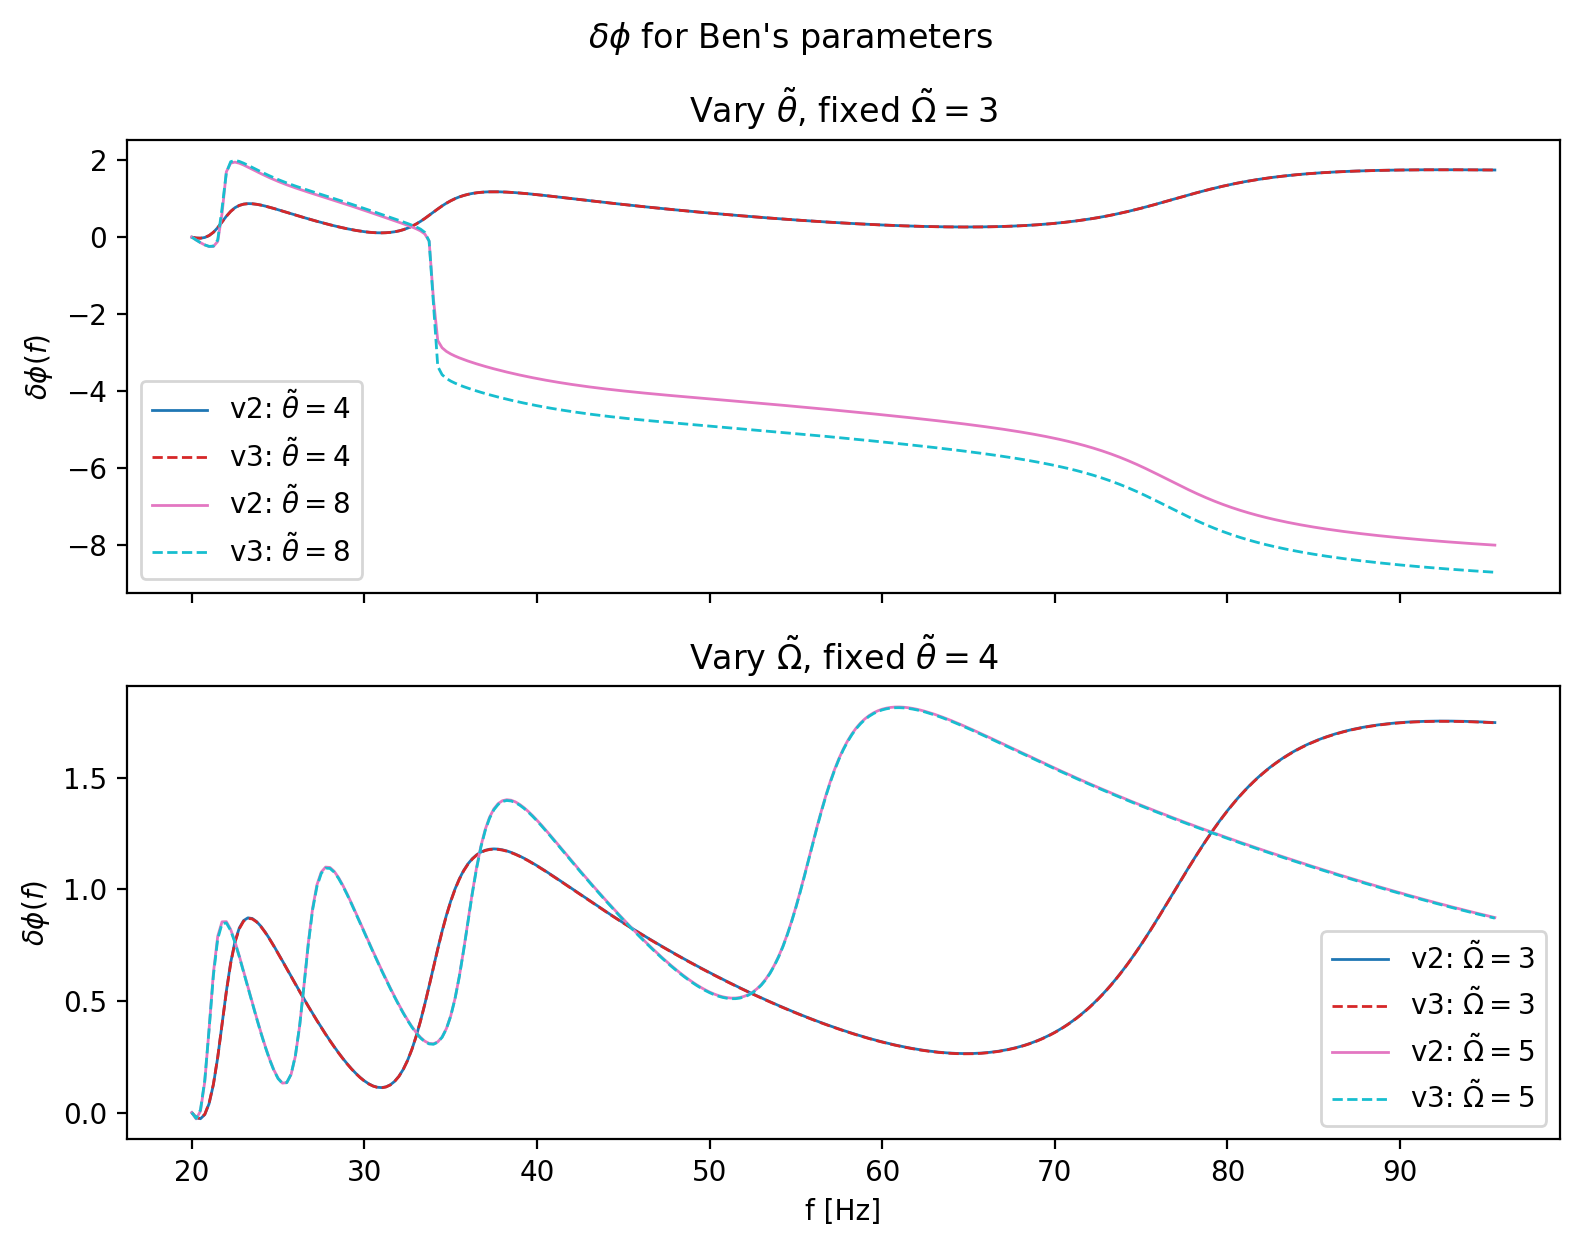

In [189]:
fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)


def plot_phase_delta_phi(
    ax, which_params, var_vals, fixed, var_name, fixed_name, colors
):
    # Map variable names to LaTeX symbols
    var_latex = {"theta_tilde": r"\tilde{\theta}", "omega_tilde": r"\tilde{\Omega}"}
    for i, var in enumerate(var_vals):
        params = which_params.copy()
        params.update({var_name: var, fixed_name: fixed})
        p2, p3 = P2(params), P3(params)
        phase2 = np.atleast_1d(p2.phase_delta_phi(f_arr))
        phase3 = np.atleast_1d(p3.phase_delta_phi(f_arr))
        label2 = rf"v2: ${var_latex.get(var_name, var_name)}={var}$"
        label3 = rf"v3: ${var_latex.get(var_name, var_name)}={var}$"
        ax.plot(f_arr, phase2, label=label2, lw=1, color=colors(2 * i), ls="-")
        ax.plot(f_arr, phase3, label=label3, lw=1, color=colors(2 * i + 1), ls="--")


# Top: vary theta_tilde, fix omega_tilde
plot_phase_delta_phi(
    axs[0],
    params_Ben,
    theta_vals,
    omega_vals[0],
    "theta_tilde",
    "omega_tilde",
    colors_top,
)
axs[0].set_ylabel(r"$\delta\phi(f)$")
axs[0].set_title(rf"Vary $\tilde{{\theta}}$, fixed $\tilde{{\Omega}}={omega_vals[0]}$")
axs[0].legend(fontsize=10)

# Bottom: vary omega_tilde, fix theta_tilde
plot_phase_delta_phi(
    axs[1],
    params_Ben,
    omega_vals,
    theta_vals[0],
    "omega_tilde",
    "theta_tilde",
    colors_bot,
)
axs[1].set_xlabel("f [Hz]")
axs[1].set_ylabel(r"$\delta\phi(f)$")
axs[1].set_title(rf"Vary $\tilde{{\Omega}}$, fixed $\tilde{{\theta}}={theta_vals[0]}$")
axs[1].legend(fontsize=10)

plt.tight_layout()
plt.suptitle(r"$\delta\phi$ for Ben's parameters", y=1.03)
plt.show()

At $\tilde{\theta} = 8$ and $\tilde{\Omega} = 3$, $\delta\phi$ from v2 and v3 are off by a constant phase shift starting from $f \sim 35$ Hz. Moreover, at those precession parameters, $\delta\phi$ jumps up and down at about the same frequencies where $\hat{L} \cdot \hat{N}$ crosses 1.

## Taman's parameters

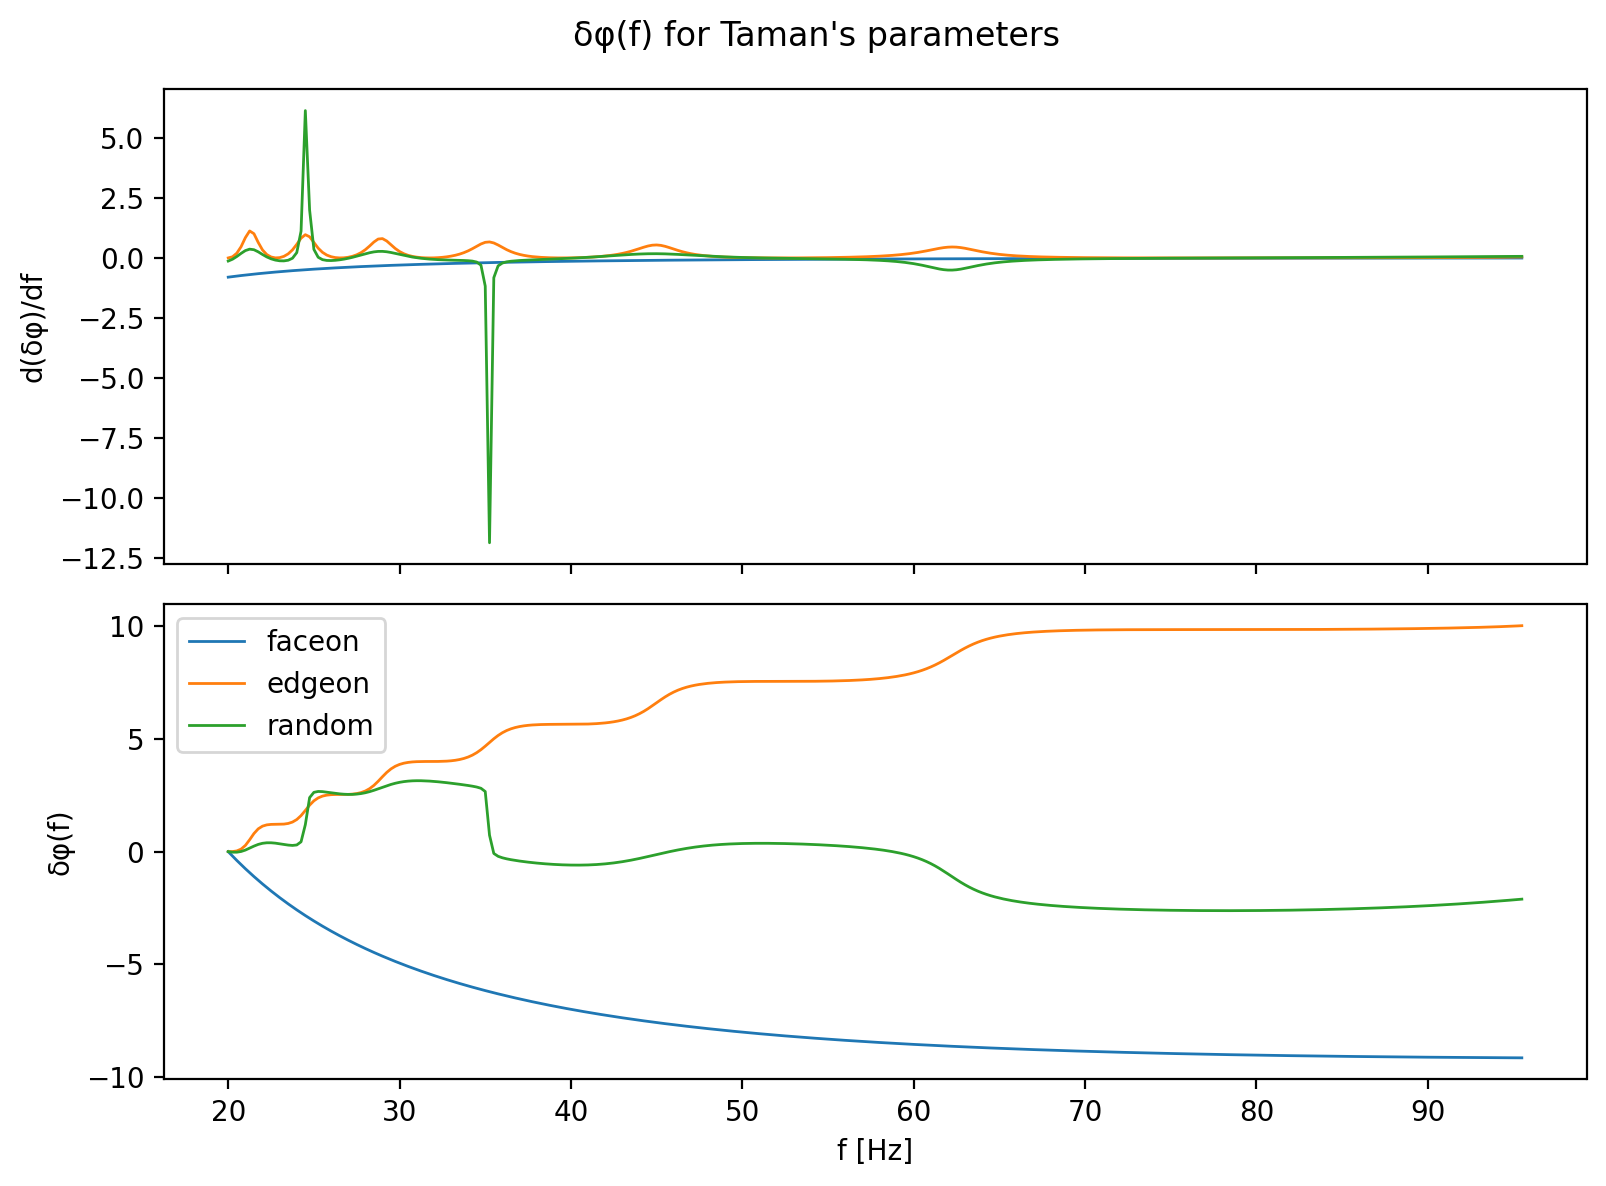

In [190]:
locations = ["faceon", "edgeon", "random"]
colors = ["tab:blue", "tab:orange", "tab:green"]

fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
for loc, color in zip(locations, colors):
    params_Taman = RP_params_1.copy()
    params_Taman.update({"theta_tilde": 15, "omega_tilde": 4, "gamma_P": 0})
    (params_Taman,) = set_to_location(loc_params["Taman"][loc], params_Taman)
    p2_Taman = P2(params_Taman)
    integrand2_Taman = np.array([p2_Taman.integrand_delta_phi(0, fi) for fi in f_arr])
    phase2_Taman = np.atleast_1d(p2_Taman.phase_delta_phi(f_arr))
    ax[0].plot(f_arr, integrand2_Taman, label=f"{loc}", lw=1, color=color)
    ax[1].plot(f_arr, phase2_Taman, label=f"{loc}", lw=1, color=color)

ax[0].set_ylabel("d(δφ)/df")
ax[1].set_ylabel("δφ(f)")
ax[1].set_xlabel("f [Hz]")
plt.legend()
plt.suptitle("δφ(f) for Taman's parameters")
plt.tight_layout()
plt.show()

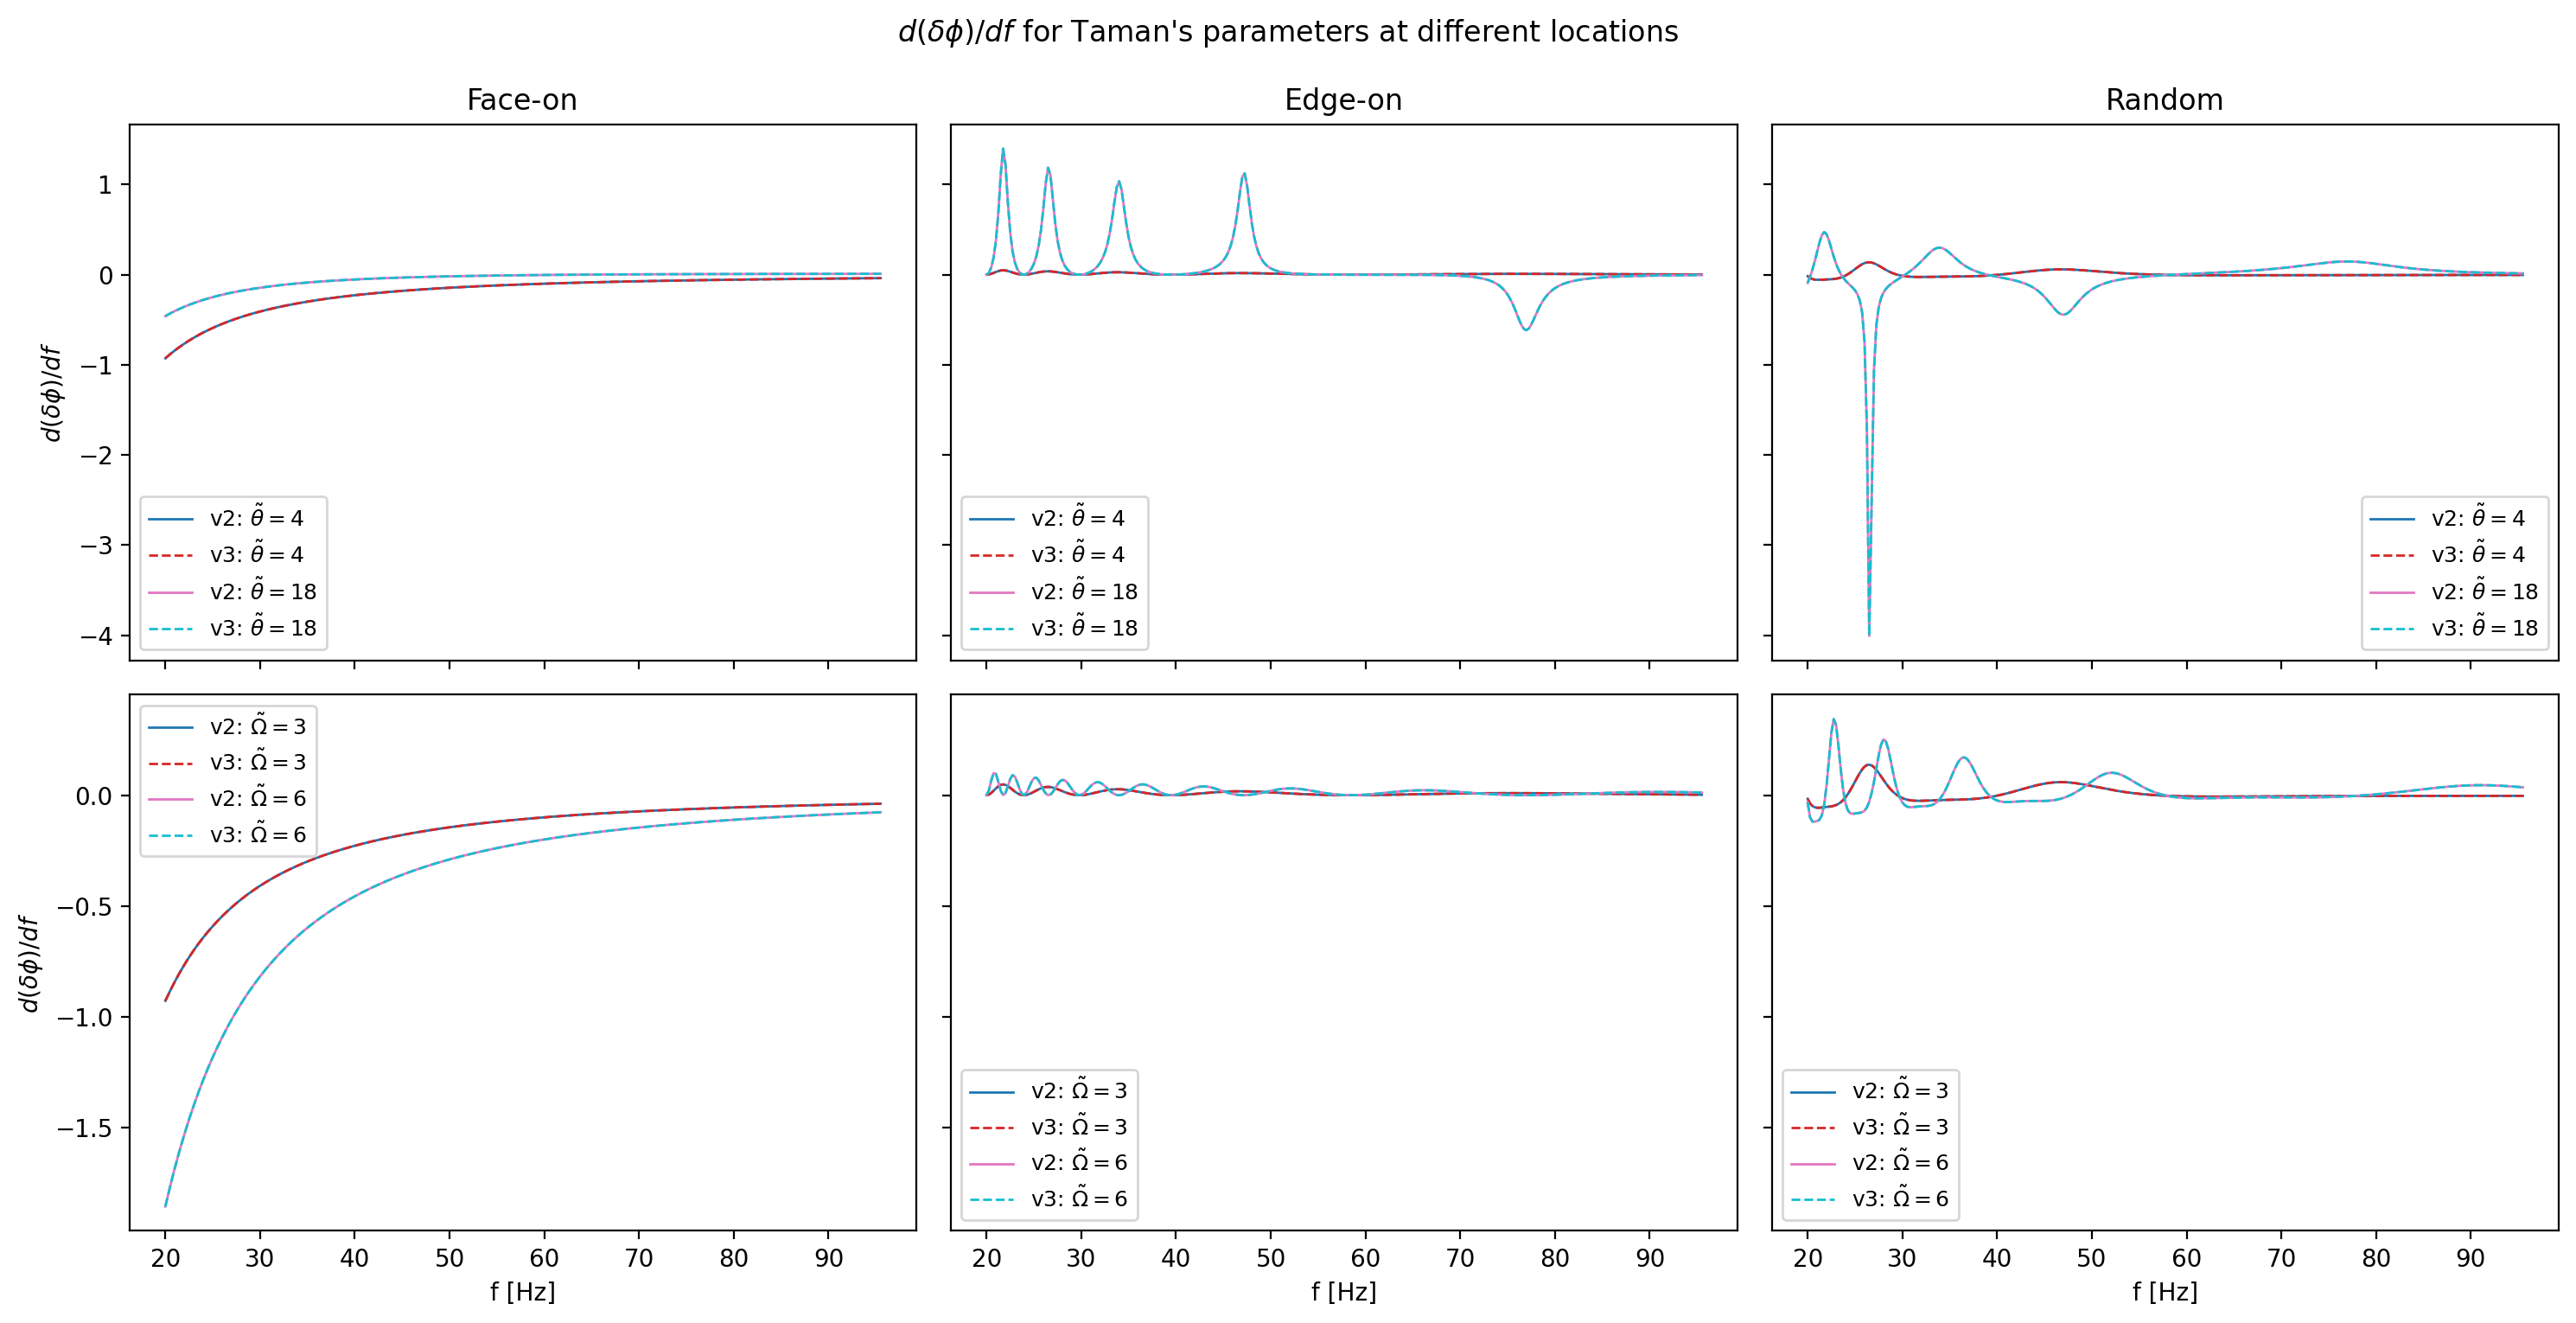

In [191]:
# 2x3 panel: columns = locations, rows = vary theta_tilde (top), vary omega_tilde (bottom)
locations = ["faceon", "edgeon", "random"]
location_titles = {"faceon": "Face-on", "edgeon": "Edge-on", "random": "Random"}
theta_vals = [4, 18]
omega_vals = [3, 6]

fig, axs = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey="row")

for col, loc in enumerate(locations):
    # Set up params for this location
    params_Taman = RP_params_1.copy()
    (params_Taman,) = set_to_location(loc_params["Taman"][loc], params_Taman)

    # Top row: vary theta_tilde, fix omega_tilde
    colors_top = mpl.colormaps.get_cmap("tab10").resampled(2 * len(theta_vals))
    plot_integrand_delta_phi(
        axs[0, col],
        params_Taman,
        theta_vals,
        omega_vals[0],
        "theta_tilde",
        "omega_tilde",
        colors_top,
    )
    axs[0, col].set_title(location_titles[loc])
    if col == 0:
        axs[0, col].set_ylabel(r"$d(\delta\phi)/df$")
    axs[0, col].legend(fontsize=9)

    # Bottom row: vary omega_tilde, fix theta_tilde
    colors_bot = mpl.colormaps.get_cmap("tab10").resampled(2 * len(omega_vals))
    plot_integrand_delta_phi(
        axs[1, col],
        params_Taman,
        omega_vals,
        theta_vals[0],
        "omega_tilde",
        "theta_tilde",
        colors_bot,
    )
    if col == 0:
        axs[1, col].set_ylabel(r"$d(\delta\phi)/df$")
    axs[1, col].set_xlabel("f [Hz]")
    axs[1, col].legend(fontsize=9)

axs[0, 1].set_title("Edge-on")
axs[0, 2].set_title("Random")
plt.suptitle(
    r"$d(\delta\phi)/df$ for Taman's parameters at different locations", y=0.95
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

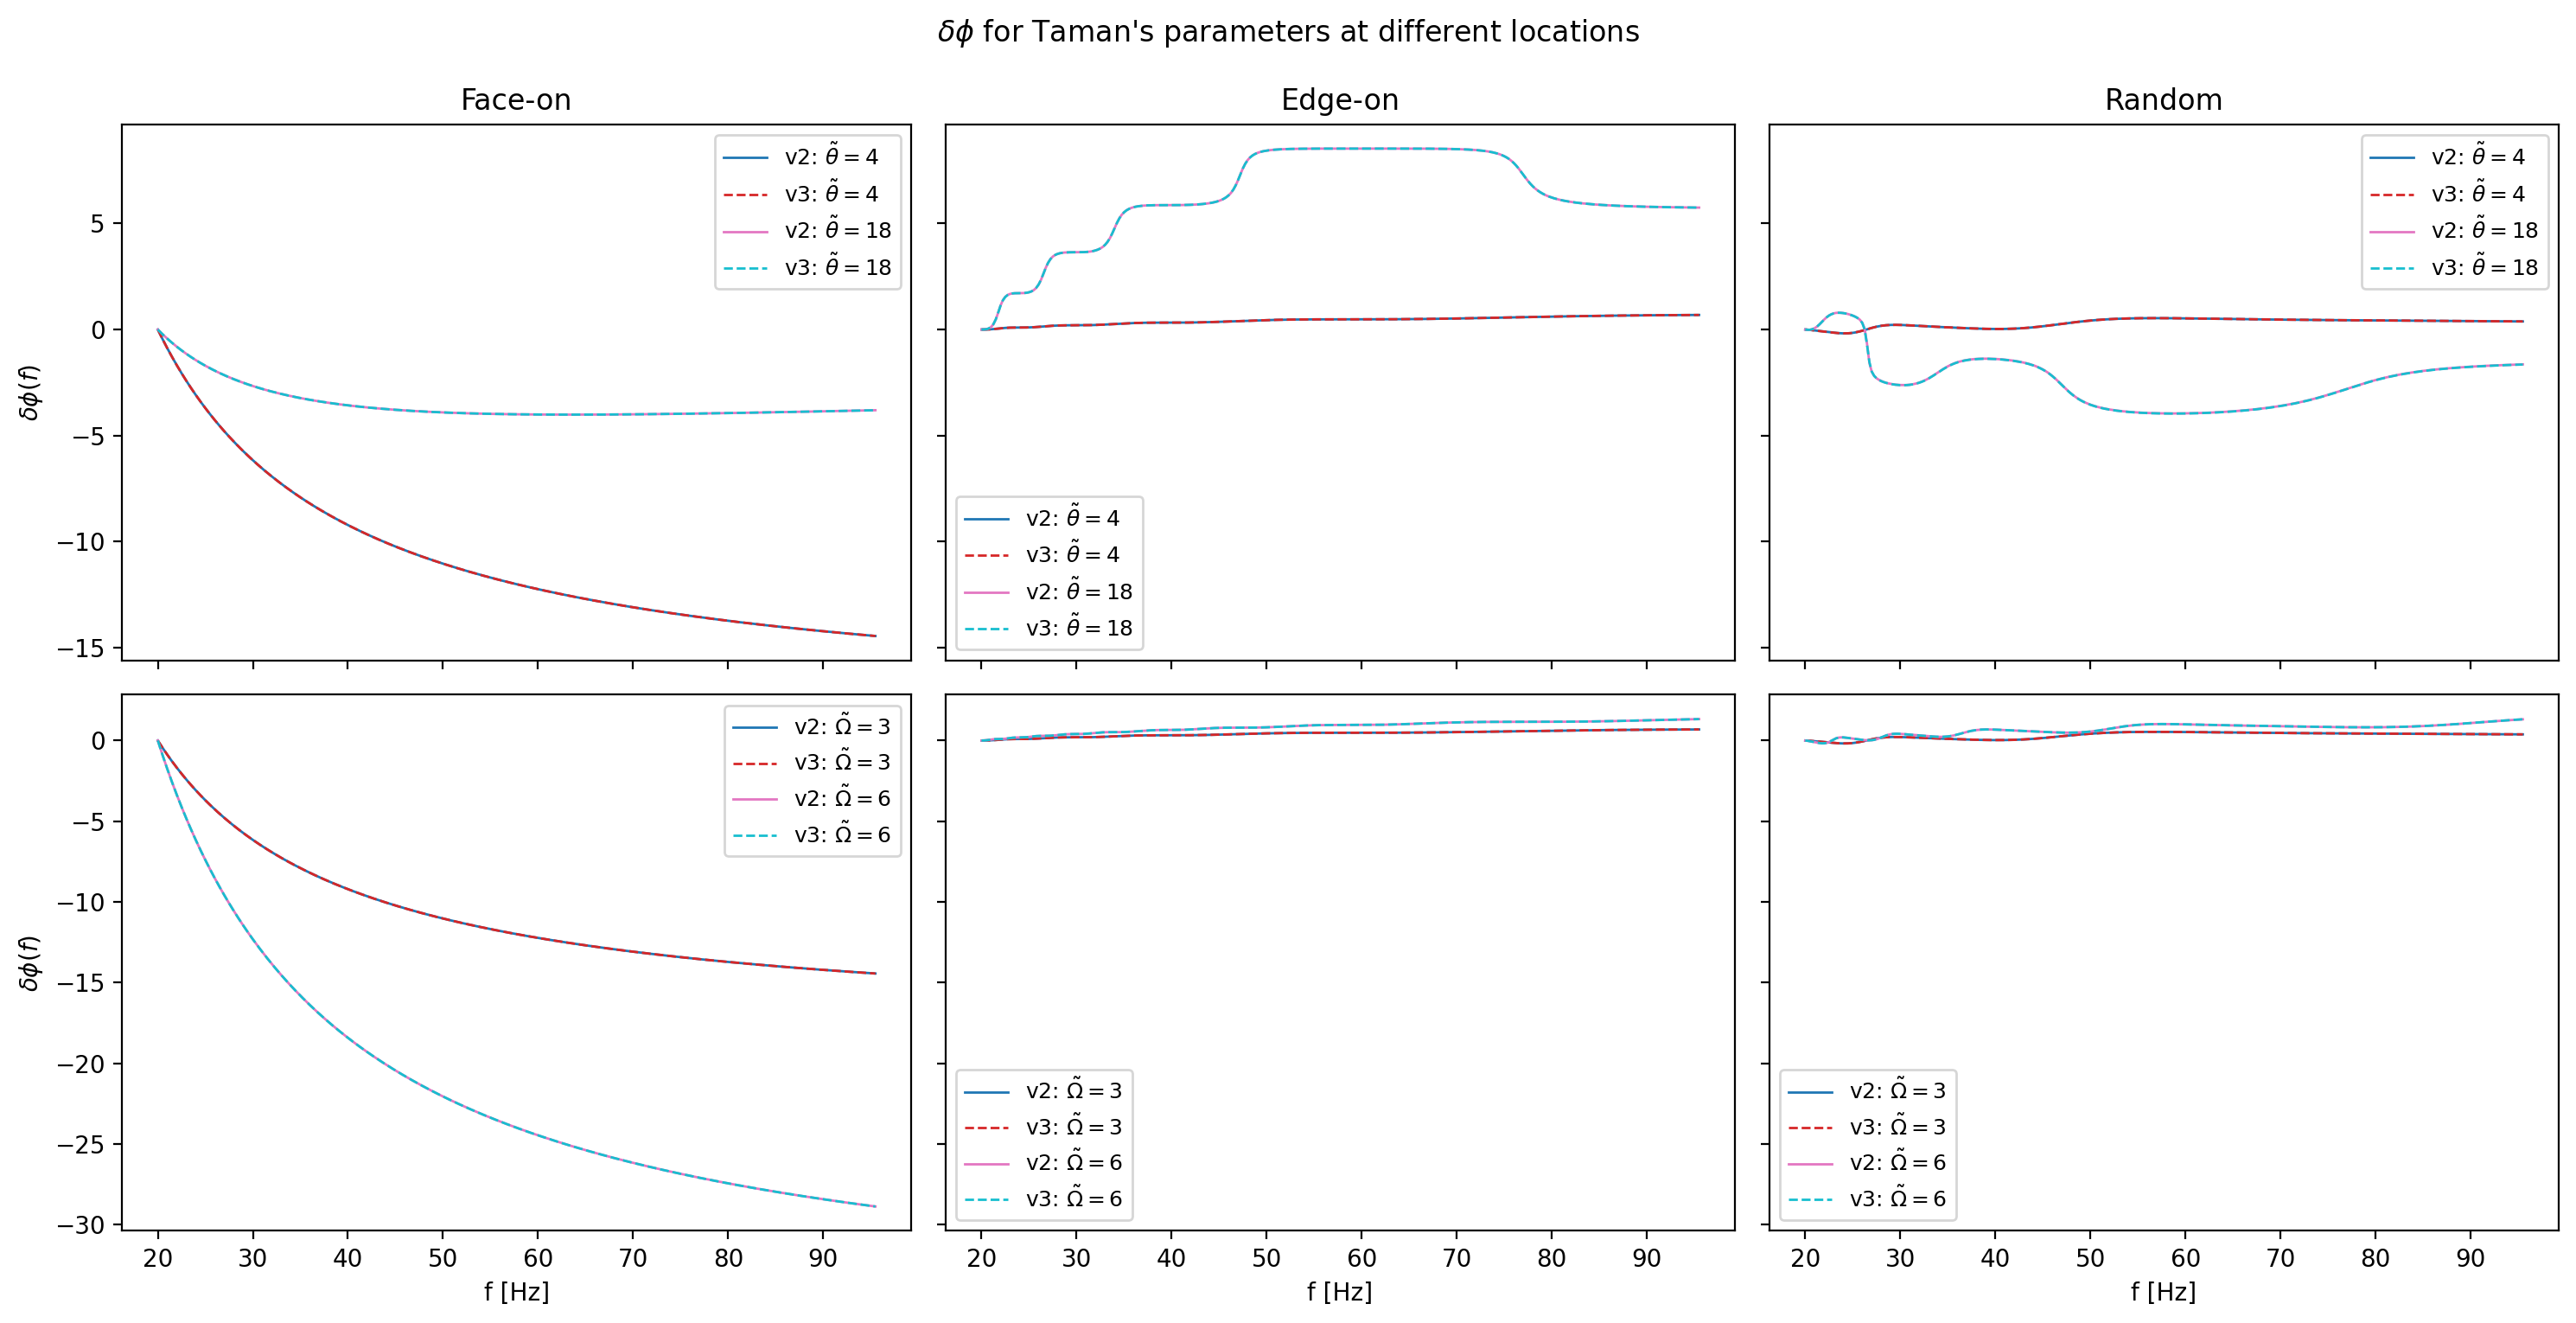

In [192]:
# 2x3 panel: columns = locations, rows = vary theta_tilde (top), vary omega_tilde (bottom)
fig, axs = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey="row")

for col, loc in enumerate(locations):
    # Set up params for this location
    params_Taman = RP_params_1.copy()
    (params_Taman,) = set_to_location(loc_params["Taman"][loc], params_Taman)

    # Top row: vary theta_tilde, fix omega_tilde
    colors_top = mpl.colormaps.get_cmap("tab10").resampled(2 * len(theta_vals))
    plot_phase_delta_phi(
        axs[0, col],
        params_Taman,
        theta_vals,
        omega_vals[0],
        "theta_tilde",
        "omega_tilde",
        colors_top,
    )
    axs[0, col].set_title(location_titles[loc])
    if col == 0:
        axs[0, col].set_ylabel(r"$\delta\phi(f)$")
    axs[0, col].legend(fontsize=9)

    # Bottom row: vary omega_tilde, fix theta_tilde
    colors_bot = mpl.colormaps.get_cmap("tab10").resampled(2 * len(omega_vals))
    plot_phase_delta_phi(
        axs[1, col],
        params_Taman,
        omega_vals,
        theta_vals[0],
        "omega_tilde",
        "theta_tilde",
        colors_bot,
    )
    if col == 0:
        axs[1, col].set_ylabel(r"$\delta\phi(f)$")
    axs[1, col].set_xlabel("f [Hz]")
    axs[1, col].legend(fontsize=9)

axs[0, 1].set_title("Edge-on")
axs[0, 2].set_title("Random")
plt.suptitle(r"$\delta\phi$ for Taman's parameters at different locations", y=0.95)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

v2 and v3 give identical results here.

# Compare polarization phase $\phi_P$
Should be the same for both v2 and v3.

## Ben's parameters

/var/folders/y_/v4l1jv1j5b55928djlvnhnm40000gp/T/ipykernel_55456/1149425630.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors_top = cm.get_cmap("tab10", len(theta_vals))
/var/folders/y_/v4l1jv1j5b55928djlvnhnm40000gp/T/ipykernel_55456/1149425630.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors_bot = cm.get_cmap("tab10", len(omega_vals))


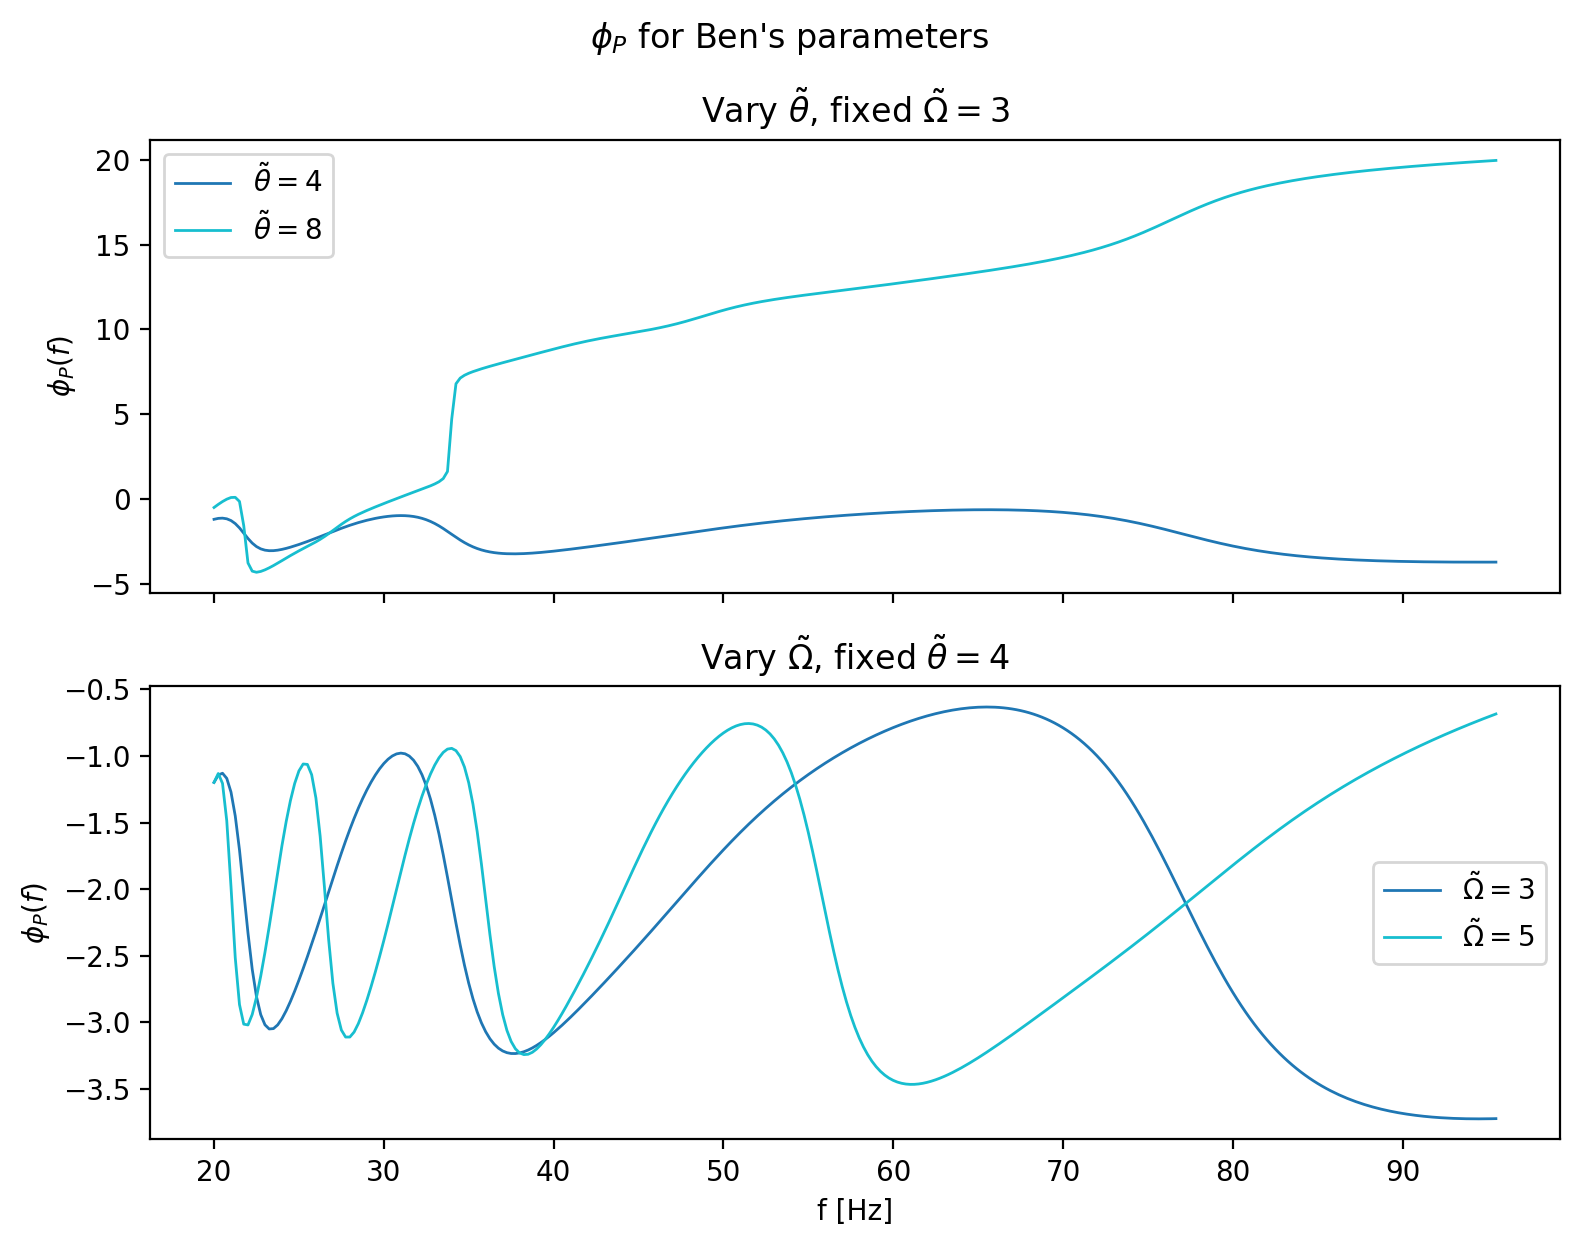

In [ ]:
theta_vals = [4, 8]
omega_vals = [3, 5]

fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
colors_top = mpl.colormaps.get_cmap("tab10").resampled(len(theta_vals))
colors_bot = mpl.colormaps.get_cmap("tab10").resampled(len(omega_vals))


def plot_phase_phi_P_v2(
    ax, which_params, var_vals, fixed, var_name, fixed_name, colors, idx=0
):
    # Map variable names to LaTeX symbols
    var_latex = {"theta_tilde": r"\tilde{\theta}", "omega_tilde": r"\tilde{\Omega}"}
    for i, var in enumerate(var_vals):
        params = which_params.copy()
        params.update({var_name: var, fixed_name: fixed})
        p2 = P2(params)
        phi2 = p2.phase_phi_P(f_arr)
        label2 = rf"${var_latex.get(var_name, var_name)}={var}$"
        ax.plot(f_arr, phi2, label=label2, lw=1, color=colors(i), ls="-")


# Top: vary theta_tilde, fix omega_tilde
plot_phase_phi_P_v2(
    axs[0],
    params_Ben,
    theta_vals,
    omega_vals[0],
    "theta_tilde",
    "omega_tilde",
    colors_top,
)
axs[0].set_ylabel(r"$\phi_P(f)$")
axs[0].set_title(rf"Vary $\tilde{{\theta}}$, fixed $\tilde{{\Omega}}={omega_vals[0]}$")
axs[0].legend(fontsize=10)

# Bottom: vary omega_tilde, fix theta_tilde
plot_phase_phi_P_v2(
    axs[1],
    params_Ben,
    omega_vals,
    theta_vals[0],
    "omega_tilde",
    "theta_tilde",
    colors_bot,
)
axs[1].set_xlabel("f [Hz]")
axs[1].set_ylabel(r"$\phi_P(f)$")
axs[1].set_title(rf"Vary $\tilde{{\Omega}}$, fixed $\tilde{{\theta}}={theta_vals[0]}$")
axs[1].legend(fontsize=10)

plt.tight_layout()
plt.suptitle(r"$\phi_P$ for Ben's parameters", y=1.03)
plt.show()

At $\tilde{\theta} = 8$ and $\tilde{\Omega} = 3$, $\phi_P$ jumps at about the same frequencies where $\hat{L} \cdot \hat{N}$ crosses 1.

## Taman's parameters

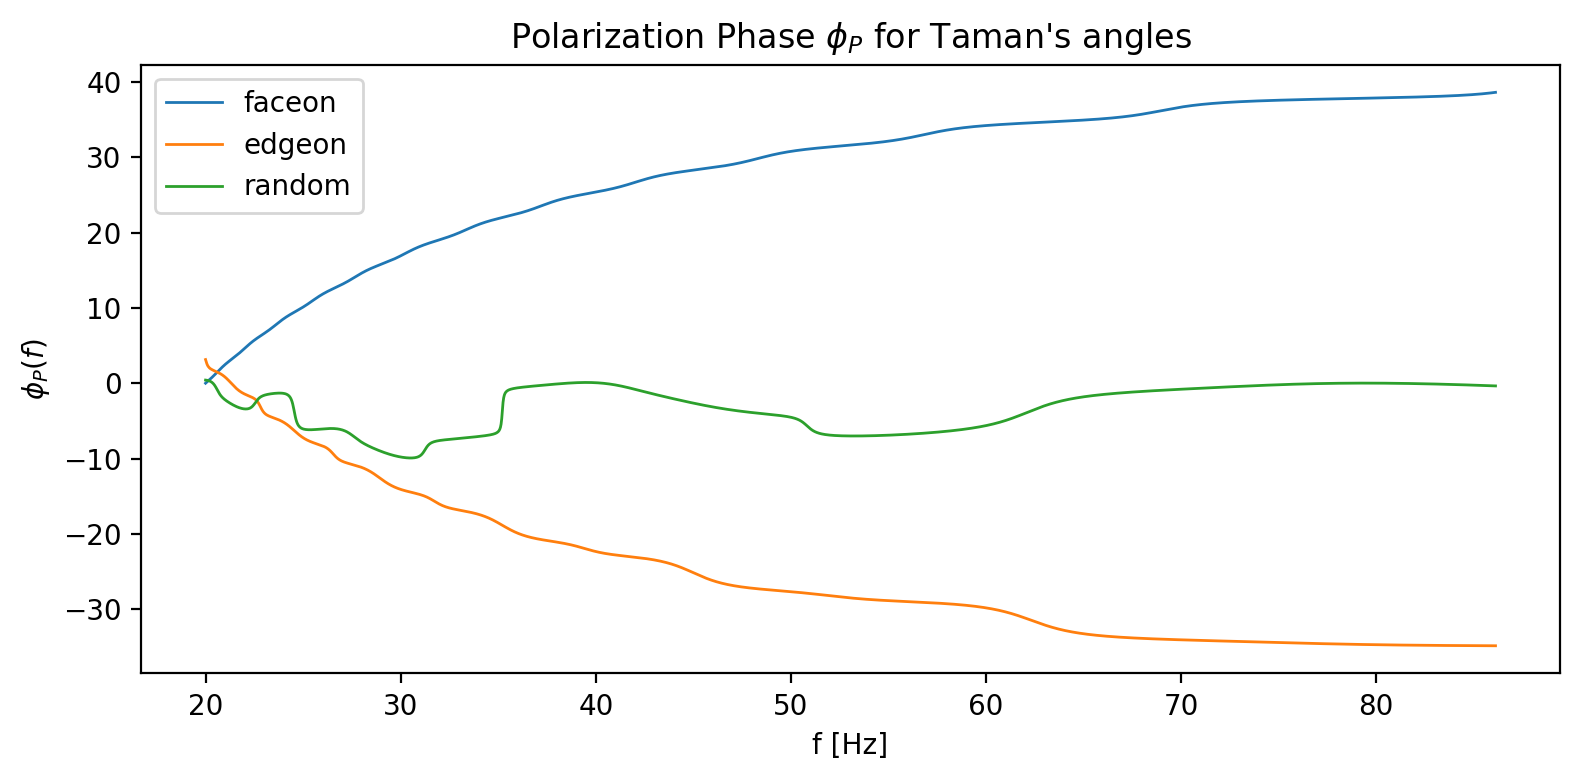

In [74]:
plt.figure(figsize=(8, 4))
for loc, color in zip(locations, colors):
    params_Taman = RP_params_1.copy()
    params_Taman.update(
        {
            "theta_tilde": 15.0,
            "omega_tilde": 4,
            "gamma_P": 0.0,
        }
    )
    (params_Taman,) = set_to_location(loc_params["Taman"][loc], params_Taman)
    p2_Taman = P2(params_Taman)
    phi_P2_Taman = p2_Taman.phase_phi_P(f_arr)
    plt.plot(f_arr, phi_P2_Taman, label=f"{loc}", lw=1, color=color)

plt.xlabel("f [Hz]")
plt.ylabel(r"$\phi_P(f)$")
plt.title("Polarization Phase $\phi_P$ for Taman's parameters")
plt.legend()
plt.tight_layout()
plt.show()

### The spin-independent GW phase at 2PN order is only dependent on total mass, chirp mass, $\eta$, $t_c$, and $\phi_c$. It is independent of $\tilde{\theta}$, $\tilde{\Omega}$, $\gamma_P$, sky location, and binary orientation.

# Compare waveforms

## Ben's parameters

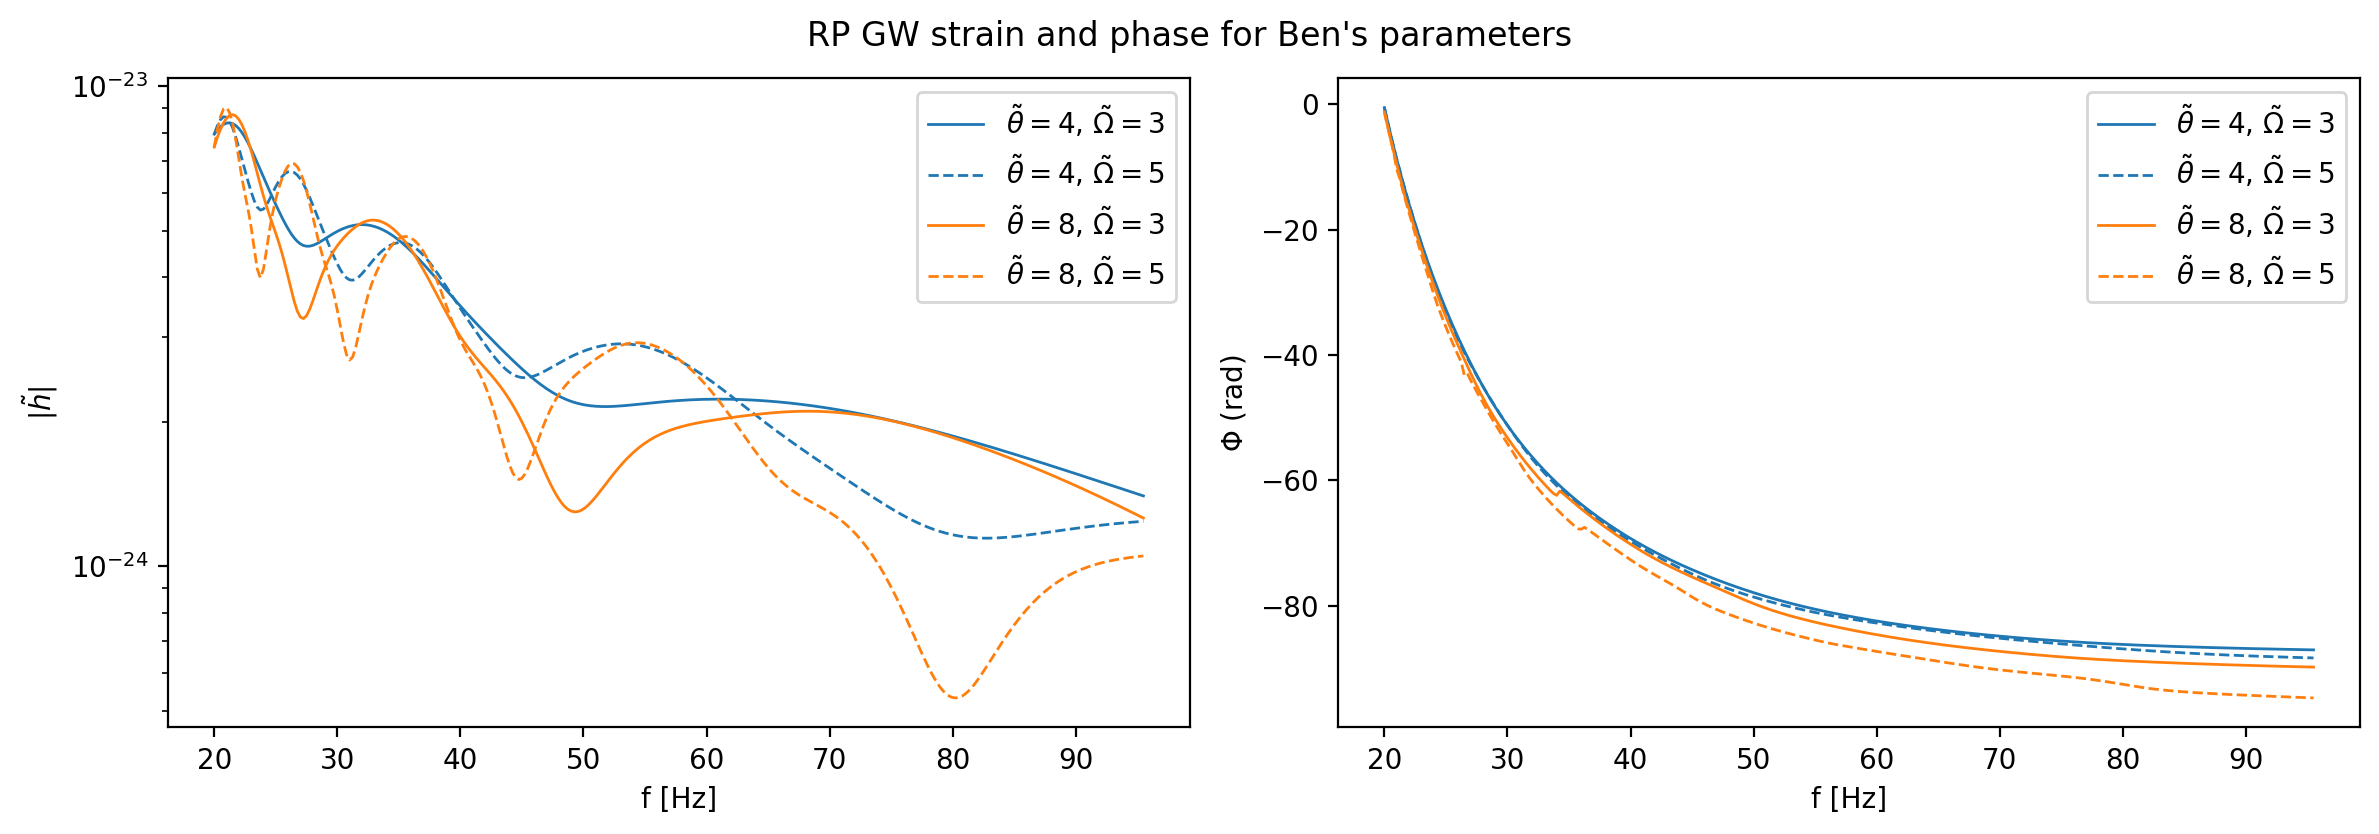

In [178]:
theta_vals = [4, 8]
omega_vals = [3, 5]
colors = ["tab:blue", "tab:orange"]
linestyles = ["-", "--"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, theta in enumerate(theta_vals):
    for j, omega in enumerate(omega_vals):
        params_Ben_var = params_Ben.copy()
        params_Ben_var.update(
            {"theta_tilde": theta, "omega_tilde": omega, "gamma_P": 0}
        )
        gw_Ben = get_gw(params_Ben_var, prec_Class=P3)
        f_arr = gw_Ben["f_array"]
        strain_Ben = gw_Ben["strain"]
        phase_Ben = gw_Ben["phase"]
        label = rf"$\tilde{{\theta}}={theta}$, $\tilde{{\Omega}}={omega}$"
        axes[0].plot(
            f_arr,
            np.abs(strain_Ben),
            label=label,
            lw=1,
            color=colors[i],
            ls=linestyles[j],
        )
        axes[1].plot(
            f_arr, phase_Ben, label=label, lw=1, color=colors[i], ls=linestyles[j]
        )

axes[0].set_xlabel("f [Hz]")
axes[0].set_ylabel(r"$|\~{h}|$")
axes[0].legend(fontsize=10)
axes[1].set_xlabel("f [Hz]")
axes[1].set_ylabel(r"$\Phi$ (rad)")
axes[0].set_yscale("log")
axes[1].legend(fontsize=10)
plt.tight_layout()
plt.suptitle("RP GW strain and phase for Ben's parameters", y=1.03)
plt.show()

In [93]:
print(params_Ben)
print(number_of_prec_cycles(params_Ben))
get_lens_limits_for_RP_L(params_Ben)

{'theta_S': 1.0471975511965976, 'phi_S': 0.7853981633974483, 'theta_J': 0.5235987755982988, 'phi_J': 1.0471975511965976, 'mcz': 9.852481519999999e-05, 'dist': 1.5439068750000003e+17, 'eta': 0.25, 't_c': 0.0, 'phi_c': 0.0, 'theta_tilde': 8, 'omega_tilde': 3, 'gamma_P': 0}
2.403243520405414


{'MLz_min': 403.8448150570481,
 'MLz_max': 3214.5359216230086,
 'td_min': 0.0039892110766206225,
 'td_max': 0.03175344049649842}

In [94]:
lens_params = lens_params_1.copy()
(lens_params,) = set_to_location(params_Ben, lens_params)
lens_params.update({"MLz": 3214 * SOLMASS2SEC})
print(number_of_lens_cycles(lens_params))

2.402842855986244


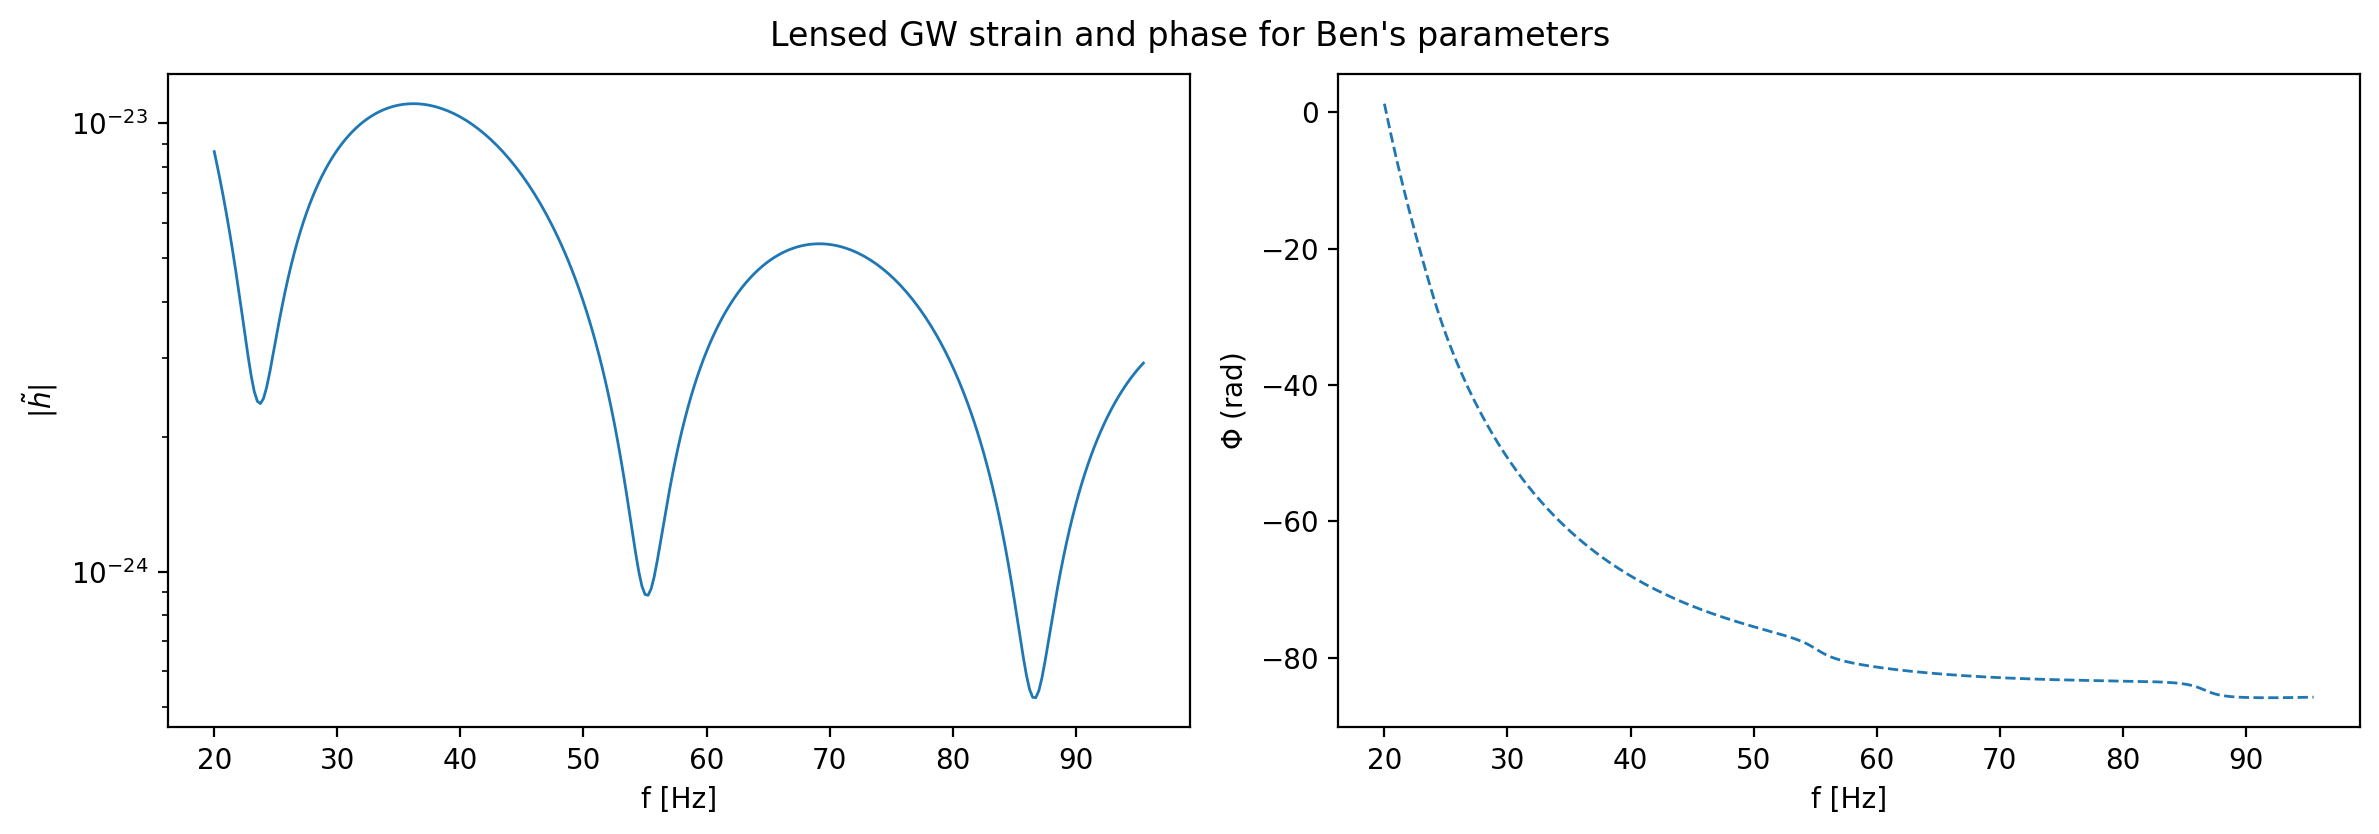

In [195]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
gw_lens = get_gw(lens_params, lens_Class=LensingGeo)
strain_lens = gw_lens["strain"]
phase_lens = gw_lens["phase"]
axes[0].plot(gw_lens["f_array"], np.abs(strain_lens), lw=1)
axes[1].plot(gw_lens["f_array"], phase_lens, lw=1, ls="--")
axes[0].set_xlabel("f [Hz]")
axes[0].set_ylabel(r"$|\~{h}|$")
axes[0].set_yscale("log")
axes[1].set_xlabel("f [Hz]")
axes[1].set_ylabel(r"$\Phi$ (rad)")
plt.tight_layout()
plt.suptitle("Lensed GW strain and phase for Ben's parameters", y=1.03)
plt.show()

In [102]:
for theta_tilde in [2, 4, 6, 8, 10]:
    tplt_params = params_Ben.copy()
    tplt_params["theta_tilde"] = theta_tilde
    start_time = time.time()
    result = optimize_mismatch_gammaP_v2(tplt_params, lens_params)
    elapsed_time = time.time() - start_time
    print(f"theta_tilde = {theta_tilde}: {result} (Elapsed time: {elapsed_time:.3f} s)")

theta_tilde = 2: {'ep_min': 0.22243067336084243, 'ep_min_gammaP': 5.7805304826052195, 'ep_min_idx': -0.1385980238945441, 'ep_min_phi': -0.33154623553128515, 'ep_max': 0.24762387836146038, 'ep_max_gammaP': 2.8902652413026098, 'ep_max_idx': -0.019908376586363317, 'ep_max_phi': 0.23815398334915597, 'ep_0': 0.22292595094993062, 'ep_0_idx': -0.12093711841482044, 'ep_0_phi': -0.41576024428868086} (Elapsed time: 1.135 s)
theta_tilde = 4: {'ep_min': 0.22029270112510002, 'ep_min_gammaP': 5.403539364174445, 'ep_min_idx': -0.4529227515000427, 'ep_min_phi': -0.6284855311490195, 'ep_max': 0.2763327988448473, 'ep_max_gammaP': 2.5132741228718345, 'ep_max_idx': -0.1829615794938038, 'ep_max_phi': 0.27762251047591424, 'ep_0': 0.23260910960483883, 'ep_0_idx': -0.42133591038393264, 'ep_0_phi': -0.9939103397800632} (Elapsed time: 1.620 s)
theta_tilde = 6: {'ep_min': 0.2150247602004477, 'ep_min_gammaP': 5.403539364174445, 'ep_min_idx': 603.0801774115779, 'ep_min_phi': -1.157852214097692, 'ep_max': 0.3241719

In [109]:
for theta_tilde in [2, 4, 6, 8, 10]:
    tplt_params = params_Ben.copy()
    tplt_params["theta_tilde"] = theta_tilde
    start_time = time.time()
    result = optimize_mismatch_gammaP_v3(tplt_params, lens_params)
    elapsed_time = time.time() - start_time
    print(f"theta_tilde = {theta_tilde}: {result} (Elapsed time: {elapsed_time:.3f} s)")

theta_tilde = 2: {'ep_min': 0.22242967108725886, 'ep_min_gammaP': 5.7805304826052195, 'ep_min_idx': -0.13860913369122924, 'ep_min_phi': -0.33051568069118853, 'ep_max': 0.24763370342989, 'ep_max_gammaP': 2.8902652413026098, 'ep_max_idx': -0.01989334754499876, 'ep_max_phi': 0.236166505545699, 'ep_0': 0.2229232886454129, 'ep_0_idx': -0.12095019699514854, 'ep_0_phi': -0.41412477873366865} (Elapsed time: 0.429 s)
theta_tilde = 4: {'ep_min': 0.22029281767827402, 'ep_min_gammaP': 5.403539364174445, 'ep_min_idx': -0.45294106909959325, 'ep_min_phi': -0.6278601829473126, 'ep_max': 0.2763716658883354, 'ep_max_gammaP': 2.5132741228718345, 'ep_max_idx': -0.18294876731797508, 'ep_max_phi': 0.2719949528592045, 'ep_0': 0.23260916816017496, 'ep_0_idx': -0.4213662676078348, 'ep_0_phi': -0.9917355373447627} (Elapsed time: 0.372 s)
theta_tilde = 6: {'ep_min': 0.21504798781836654, 'ep_min_gammaP': 5.403539364174445, 'ep_min_idx': 603.0801983462846, 'ep_min_phi': -1.1575688037873442, 'ep_max': 0.43454310301

$\tilde{\theta}$ = 8 and $\tilde{\Omega}$ = 3 is where $\delta\phi$ shifts by a constant phase starting from $f \sim 35$ Hz between v2 and v3 (see above)! There, the mismatch with the lensed source went from 0.256 (v2) to 0.248 (v3) despite being the same parameters!!!

The execution time is 2-5x faster for v3!!!

idx = -2.57e-08, phi = -1.63e-08, both should be ~0 if get_updated_mismatch_results is True


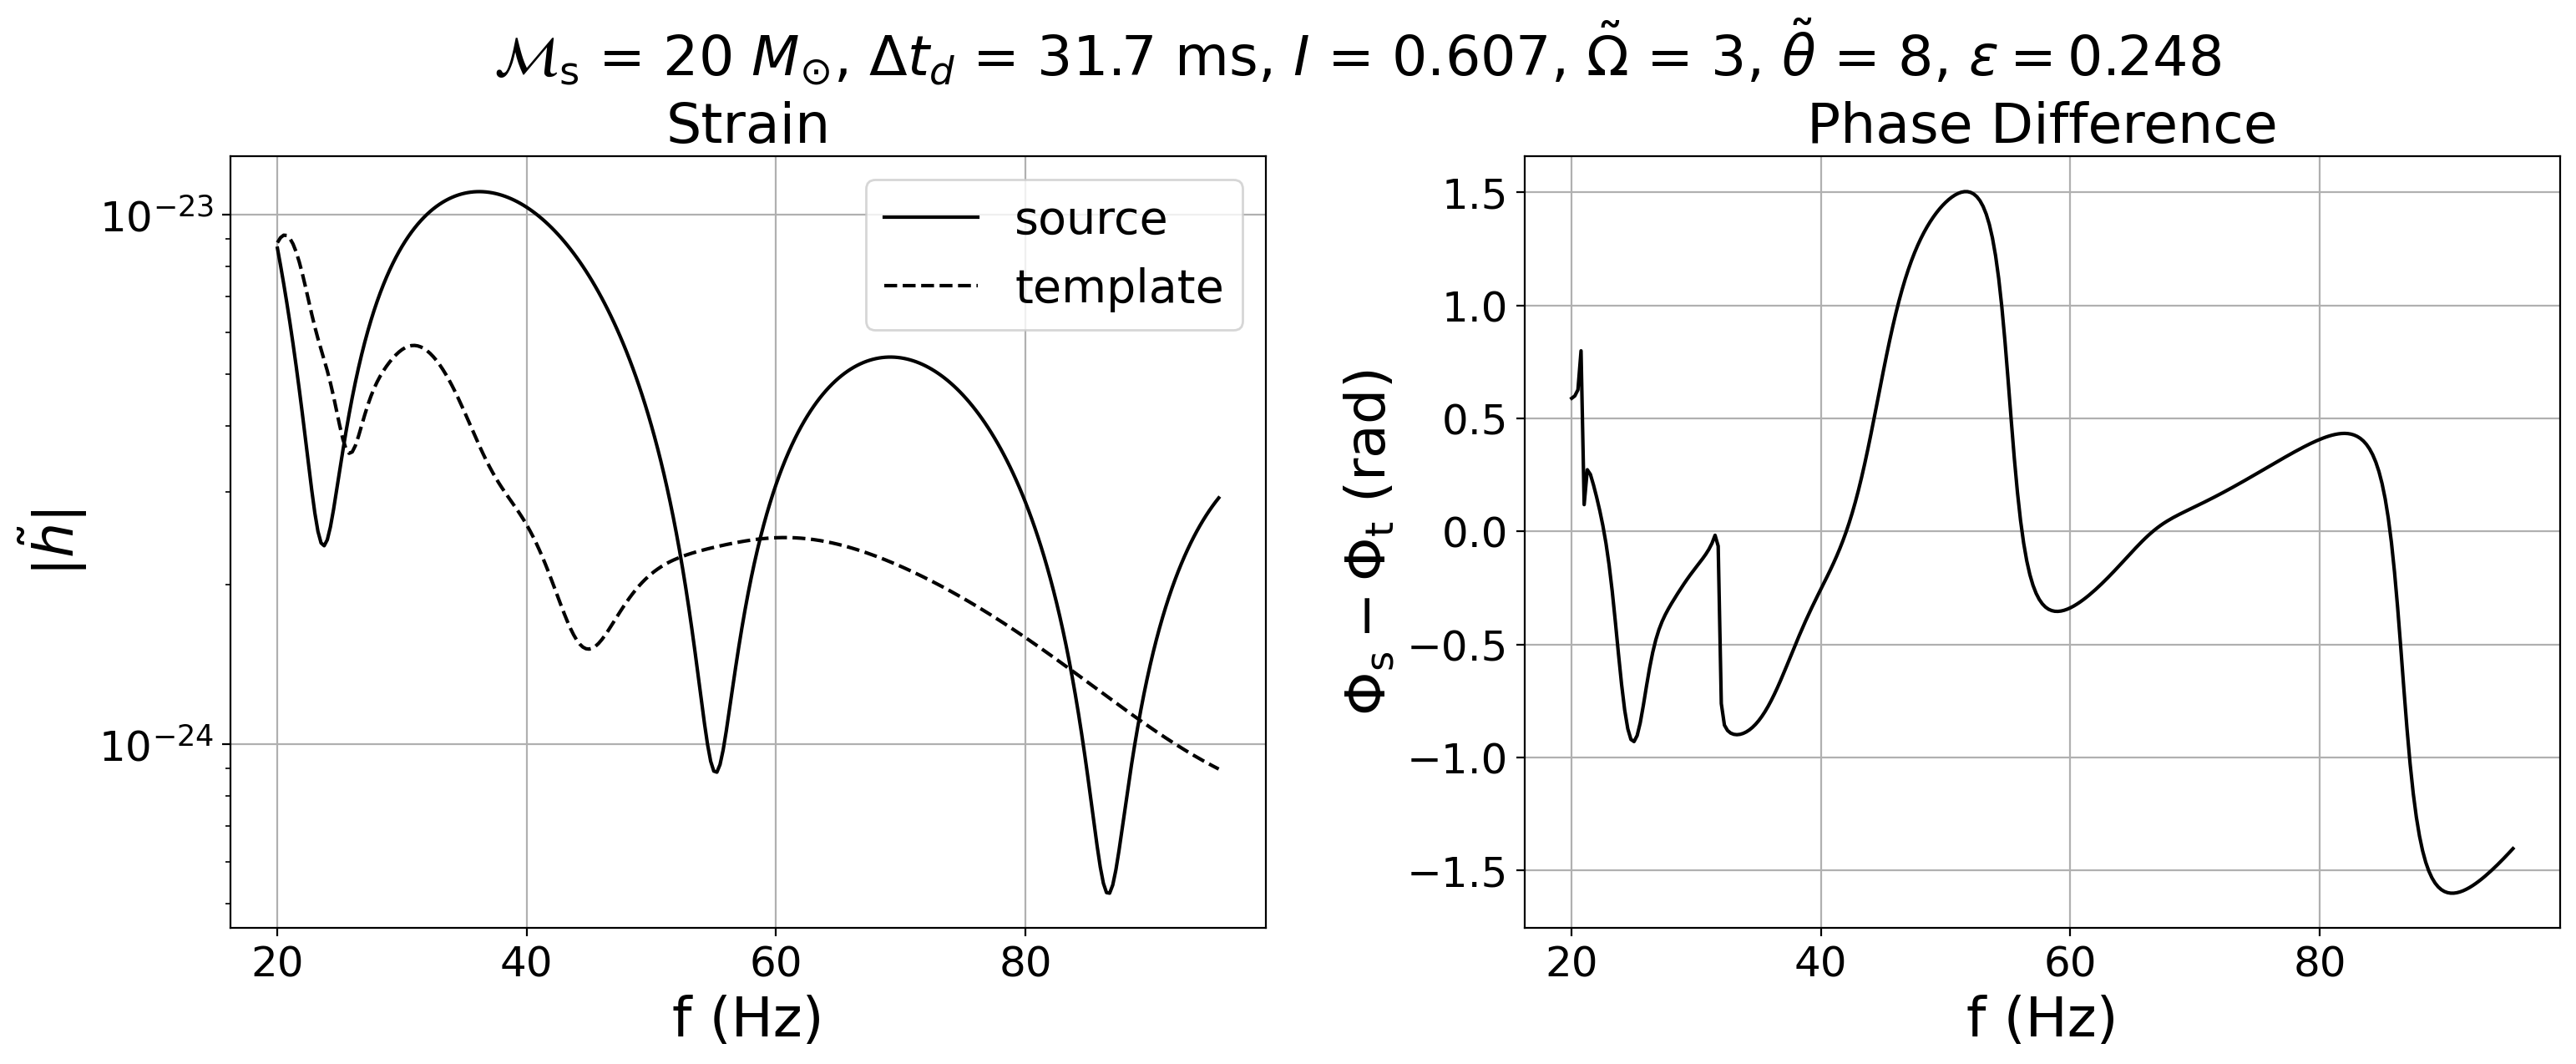

In [113]:
plot_standalone_waveform_comparison(
    params_Ben, lens_params, get_updated_mismatch_results=True
)

## Taman's parameters